In [1]:
import pandas as pd
import seaborn as sns 
import matplotlib.pyplot as plt
import numpy as np


- Download datasets from the links provided in README
- Place them in the same folder as this notebook

# Load Datasets

In [2]:
fear_greed=pd.read_csv("fear_greed_index.csv")
historical_data=pd.read_csv("historical_data.csv")

# Data Cleaning
The historical trading dataset contains several fields such as transaction hashes, order IDs, and trade IDs that are primarily identifiers and do not contribute to trader behavior analysis. Therefore, only relevant columns were retained: Account, Coin, Size USD, Side, Timestamp IST, Direction, and Closed PnL.

This helps simplify the dataset while keeping the features required for analyzing trading behavior.

In [3]:
cols = [
    'Account',
    'Coin',
    'Size USD',
    'Side',
    'Timestamp IST',
    'Closed PnL',
    'Direction'
]

df = historical_data[cols]
df.head()

,Account,Coin,Size USD,Side,Timestamp IST,Closed PnL,Direction
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7872.16,BUY,02-12-2024 22:50,0.0,Buy
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,127.68,BUY,02-12-2024 22:50,0.0,Buy
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,1150.63,BUY,02-12-2024 22:50,0.0,Buy
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,1142.04,BUY,02-12-2024 22:50,0.0,Buy
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,69.75,BUY,02-12-2024 22:50,0.0,Buy


# Timestamps to date.

In [4]:
df['Timestamp IST'] = pd.to_datetime(df['Timestamp IST'],dayfirst=True)
df['date'] = df['Timestamp IST'].dt.date
df=df.drop(columns=["Timestamp IST"])

C:\Users\Omkar\AppData\Local\Temp\ipykernel_6032\428247655.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Timestamp IST'] = pd.to_datetime(df['Timestamp IST'],dayfirst=True)
C:\Users\Omkar\AppData\Local\Temp\ipykernel_6032\428247655.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['date'] = df['Timestamp IST'].dt.date


In [5]:
fear_greed['date'] = pd.to_datetime(fear_greed['date']).dt.date

# Merging both datasets on the basis of 'date'

In [6]:
merged = df.merge(
    fear_greed[['date','classification']],
    on='date',
    how='left'
)

In [7]:
merged.columns

Index(['Account', 'Coin', 'Size USD', 'Side', 'Closed PnL', 'Direction',
       'date', 'classification'],
      dtype='object')

# Feature Engineering

In [8]:
# Win column
merged['win'] = merged['Closed PnL'] > 0

# Daily PnL per trader
daily_pnl = merged.groupby(['Account','date'])['Closed PnL'].sum().reset_index()

# Win rate per trader
win_rate = merged.groupby('Account')['win'].mean().reset_index()

# Trade Frequency per Day
trades_per_day = merged.groupby('date').size().reset_index(name='trades')


In [9]:
# Long vs Short Ratio
merged['Direction'].value_counts(normalize=True)

Direction
Open Long                    0.236218
Close Long                   0.230457
Open Short                   0.188146
Close Short                  0.170497
Sell                         0.094222
Buy                          0.079139
Spot Dust Conversion         0.000672
Short > Long                 0.000331
Long > Short                 0.000270
Auto-Deleveraging            0.000038
Liquidated Isolated Short    0.000005
Settlement                   0.000005
Name: proportion, dtype: float64

# Exploratory data analysis

In [10]:
# Average PnL by Sentiment
merged.groupby('classification')['Closed PnL'].mean()

classification
Extreme Fear     34.537862
Extreme Greed    67.892861
Fear             54.290400
Greed            42.743559
Neutral          34.307718
Name: Closed PnL, dtype: float64

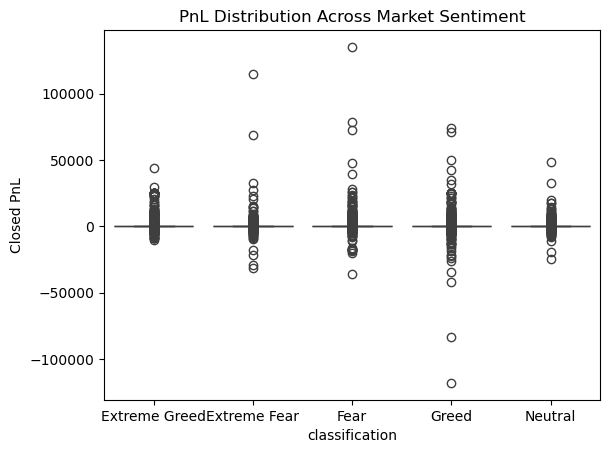

In [11]:
# PnL vs Sentiment
sns.boxplot(data=merged, x='classification', y='Closed PnL')
plt.title("PnL Distribution Across Market Sentiment")
plt.show()

## Trader profitability is highest during Extreme Greed periods, suggesting bullish markets provide stronger profit opportunities.

In [12]:
# Trade size by sentiment
merged.groupby('classification')['Size USD'].mean()

classification
Extreme Fear     5349.731843
Extreme Greed    3112.251565
Fear             7816.109931
Greed            5736.884375
Neutral          4782.732661
Name: Size USD, dtype: float64

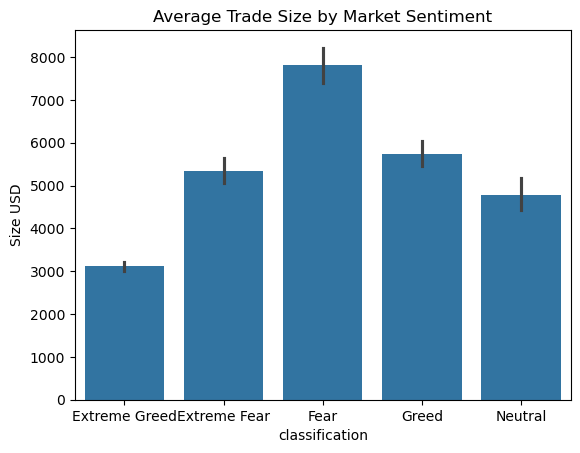

In [13]:
# Trade Size vs Sentiment
sns.barplot(data=merged, x='classification', y='Size USD')
plt.title("Average Trade Size by Market Sentiment")
plt.show()

## Average trade size increases during Fear sentiment, indicating traders take larger positions during volatile markets.

In [14]:
merged['position_type'] = merged['Direction'].apply(
    lambda x: 'Long' if 'Long' in str(x) else ('Short' if 'Short' in str(x) else 'Other')
)
merged['position_type'].value_counts()

position_type
Long     98700
Short    75755
Other    36769
Name: count, dtype: int64

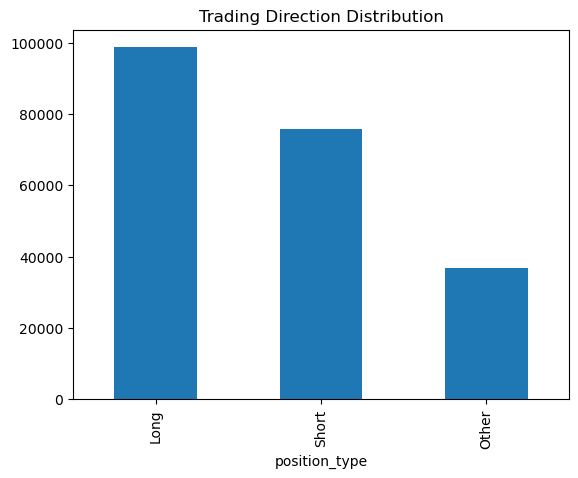

In [15]:
# Long vs Short Ratio
merged['position_type'].value_counts().plot(kind='bar')
plt.title("Trading Direction Distribution")
plt.show()

## Trading activity varies with sentiment, suggesting trader behavior adapts to market conditions.

# Trader Segmentation

In [16]:
## Frequent vs Infrequent Traders
trades_per_trader = merged.groupby('Account').size().reset_index(name='trade_count')
median_trades = trades_per_trader['trade_count'].median()

trades_per_trader['trader_type'] = trades_per_trader['trade_count'].apply(
    lambda x: 'Frequent Trader' if x > median_trades else 'Infrequent Trader'
)

In [17]:
## Consistent vs Inconsistent Traders
merged['win'] = merged['Closed PnL'] > 0

win_rate = merged.groupby('Account')['win'].mean().reset_index()
win_rate['trader_category'] = win_rate['win'].apply(
    lambda x: 'Consistent Winner' if x > 0.6 else 'Inconsistent Winner'
)

In [18]:
## High vs Low Trade Size
median_size = merged['Size USD'].median()

merged['size_segment'] = merged['Size USD'].apply(
    lambda x: 'High Value Trade' if x > median_size else 'Low Value Trade'
)

Text(0.5, 1.0, 'Frequent vs Infrequent Traders')

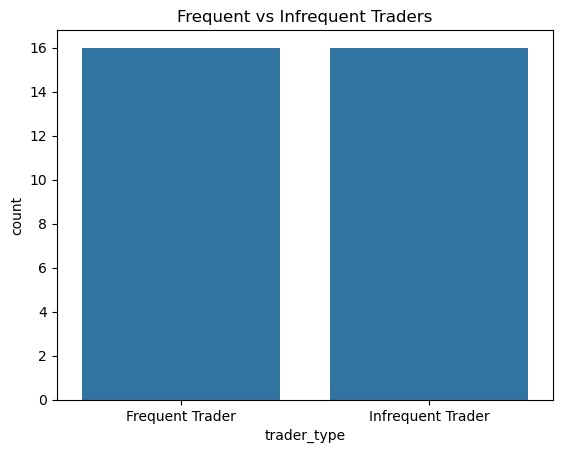

In [19]:
sns.countplot(data=trades_per_trader, x='trader_type')
plt.title("Frequent vs Infrequent Traders")

Text(0.5, 1.0, 'Winning consistency')

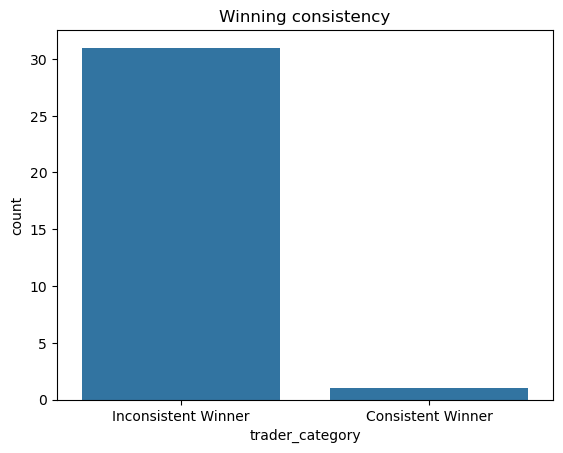

In [20]:
sns.countplot(data=win_rate, x='trader_category')
plt.title("Winning consistency")

## Consistent winning traders represent a smaller portion of the dataset, indicating that sustained profitability is challenging in trading environments.

# Strategy Recommendations

- During Extreme Greed periods, traders may increase trading activity since average profitability is higher.
- During Fear periods, traders should control trade sizes since market volatility tends to increase.

# Conclusion

- This analysis explored how trader behavior and performance vary across different market sentiment conditions. The results suggest that sentiment influences both profitability and trading behavior, with notable differences observed between Fear and Greed periods.